<a href="https://colab.research.google.com/github/varshithkuravati/ML-practice/blob/main/ML01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [ ]:
# getting the dataset.
path = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

headnames = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

dataset = pd.read_csv(path, names = headnames)

dataset.head()


# data preprocessing stage.


x = dataset.iloc[:,:-1]
y = dataset.iloc[:,4]

# instead of going for train and test
# iam going with train, test and validation

x_train, x_temp, y_train, y_temp = train_test_split(x,y, test_size = 0.3)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size = 0.5)

scaler = StandardScaler()

scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

classifier = KNeighborsClassifier(n_neighbors = 8)
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
# print(f1_score(y_test, y_pred, average = 'weighted'))




[[10  0  0]
 [ 0  7  0]
 [ 0  0  5]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         7
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        22
      macro avg       1.00      1.00      1.00        22
   weighted avg       1.00      1.00      1.00        22

1.0


# Week 3

In [1]:
import kagglehub
path = kagglehub.dataset_download("hasibullahaman/traffic-prediction-dataset")

100%|██████████| 83.1k/83.1k [00:00<00:00, 10.7MB/s]

Extracting files...


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay, precision_score, recall_score


# loading the data
data = pd.read_csv(os.path.join(path, "Traffic.csv"))

dt_column = pd.to_datetime(data["Time"],format="%I:%M:%S %p")

dt_column = dt_column.dt.hour * 60 + dt_column.dt.minute

data["Time"] = dt_column

label_encoder = LabelEncoder()

data["Day of the week"] = label_encoder.fit_transform(data["Day of the week"])

data["Traffic Situation"] = label_encoder.fit_transform(data["Traffic Situation"])

x = data.drop('Traffic Situation', axis=1)
y = data["Traffic Situation"]

x_train, x_temp, y_train, y_temp = train_test_split(x,y, test_size = 0.3, random_state=40)

x_test, x_val, y_test, y_val = train_test_split(x_temp,y_temp, test_size = 0.33333, random_state=41)

scaler = StandardScaler()

scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)




Classification Report
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       125
           1       0.94      0.74      0.83        62
           2       0.77      0.85      0.81        52
           3       0.94      0.94      0.94       356

    accuracy                           0.91       595
   macro avg       0.89      0.87      0.88       595
weighted avg       0.92      0.91      0.91       595



Accuracy Score: 0.9142857142857143 

Precision Score: 0.9160423897756601 

Recall Score: 0.9142857142857143 

F1 Score: 0.9136674169336234 


 Confusion Matrix


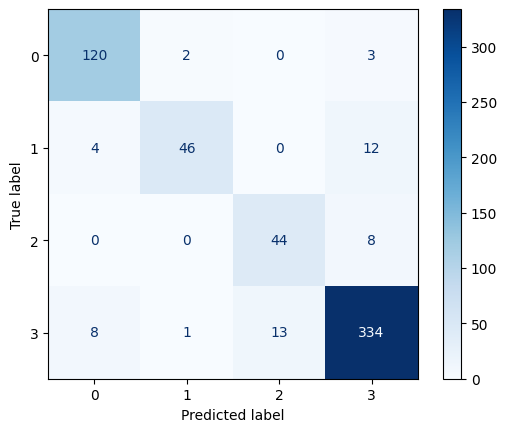

In [10]:
#KNN completed

classifier = KNeighborsClassifier(n_neighbors = 8)
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)

print("Classification Report")

print(classification_report(y_test, y_pred))

print("\n")

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)} \n")
print(f"Precision Score: {precision_score(y_test,y_pred, average='weighted')} \n")
print(f"Recall Score: {recall_score(y_test,y_pred, average='weighted')} \n")
print(f"F1 Score: {f1_score(y_test,y_pred, average='weighted')} \n")

print("\n Confusion Matrix")

labels = [0,1,2,3]
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels)
disp.plot(cmap='Blues', values_format='d')


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       125
           1       1.00      1.00      1.00        62
           2       1.00      1.00      1.00        52
           3       1.00      1.00      1.00       356

    accuracy                           1.00       595
   macro avg       1.00      1.00      1.00       595
weighted avg       1.00      1.00      1.00       595



Accuracy Score: 1.0 

Precision Score: 1.0 

Recall Score: 1.0 

F1 Score: 1.0 


 Confusion Matrix


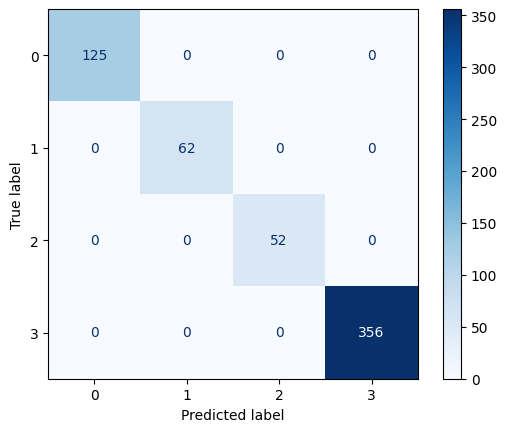

In [9]:
dtc = DecisionTreeClassifier()

dtc.fit(x_train, y_train)

y_pred = dtc.predict(x_test)

print("Classification Report")

print(classification_report(y_test, y_pred))

print("\n")

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)} \n")
print(f"Precision Score: {precision_score(y_test,y_pred, average='weighted')} \n")
print(f"Recall Score: {recall_score(y_test,y_pred, average='weighted')} \n")
print(f"F1 Score: {f1_score(y_test,y_pred, average='weighted')} \n")

print("\n Confusion Matrix")

labels = [0,1,2,3]
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels)
disp.plot(cmap='Blues', values_format='d')



Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       125
           1       0.98      0.82      0.89        62
           2       0.88      0.98      0.93        52
           3       0.97      0.97      0.97       356

    accuracy                           0.96       595
   macro avg       0.95      0.94      0.94       595
weighted avg       0.96      0.96      0.96       595



Accuracy Score: 0.9613445378151261 

Precision Score: 0.9624468256243339 

Recall Score: 0.9613445378151261 

F1 Score: 0.960879600154118 


 Confusion Matrix


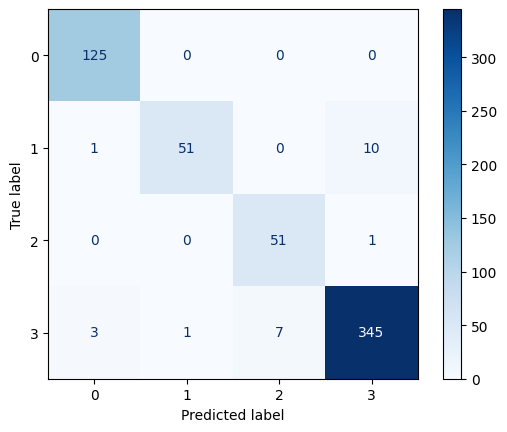

In [8]:
from sklearn.svm import SVC

# SVM

svm_model = SVC(kernel="rbf",C=5.0,random_state=40)

svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)

print("Classification Report")

print(classification_report(y_test, y_pred))

print("\n")

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)} \n")
print(f"Precision Score: {precision_score(y_test,y_pred, average='weighted')} \n")
print(f"Recall Score: {recall_score(y_test,y_pred, average='weighted')} \n")
print(f"F1 Score: {f1_score(y_test,y_pred, average='weighted')} \n")

print("\n Confusion Matrix")

labels = [0,1,2,3]
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels)
disp.plot(cmap='Blues', values_format='d')


Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       125
           1       0.98      1.00      0.99        62
           2       1.00      1.00      1.00        52
           3       1.00      0.99      1.00       356

    accuracy                           0.99       595
   macro avg       0.99      1.00      0.99       595
weighted avg       1.00      0.99      0.99       595



Accuracy Score: 0.9949579831932773 

Precision Score: 0.9950375950905296 

Recall Score: 0.9949579831932773 

F1 Score: 0.9949673773787842 


 Confusion Matrix


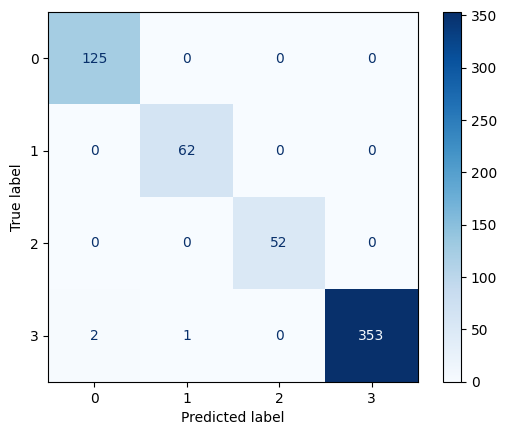

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Random forest

random_model = RandomForestClassifier(n_estimators=100, random_state=40)

random_model.fit(x_train, y_train)

y_pred = random_model.predict(x_test)

print("Classification Report")

print(classification_report(y_test, y_pred))

print("\n")

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)} \n")
print(f"Precision Score: {precision_score(y_test,y_pred, average='weighted')} \n")
print(f"Recall Score: {recall_score(y_test,y_pred, average='weighted')} \n")
print(f"F1 Score: {f1_score(y_test,y_pred, average='weighted')} \n")

print("\n Confusion Matrix")

labels = [0,1,2,3]
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels)
disp.plot(cmap='Blues', values_format='d')


In [19]:
pip install xgboost

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       125
           1       1.00      1.00      1.00        62
           2       1.00      1.00      1.00        52
           3       1.00      1.00      1.00       356

    accuracy                           1.00       595
   macro avg       1.00      1.00      1.00       595
weighted avg       1.00      1.00      1.00       595



Accuracy Score: 1.0 

Precision Score: 1.0 

Recall Score: 1.0 

F1 Score: 1.0 


 Confusion Matrix


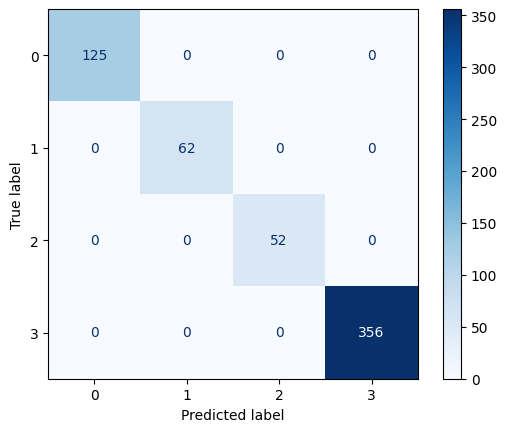

In [20]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(n_estimators=155, learning_rate=0.01, max_depth=5, random_state=40)
xgb_model.fit(x_train, y_train)


y_pred = xgb_model.predict(x_test)


print("Classification Report")

print(classification_report(y_test, y_pred))

print("\n")

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)} \n")
print(f"Precision Score: {precision_score(y_test,y_pred, average='weighted')} \n")
print(f"Recall Score: {recall_score(y_test,y_pred, average='weighted')} \n")
print(f"F1 Score: {f1_score(y_test,y_pred, average='weighted')} \n")

print("\n Confusion Matrix")

labels = [0,1,2,3]
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
